In [1]:
import torch, os, torchvision.transforms as transforms, copy, pickle
import torch.nn as nn
import torchvision
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import lr_scheduler

In [2]:
batch_size = 128
num_epochs = 300
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    ),
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    ),
])

In [11]:
full_train = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True)

train_size = int(0.9 * len(full_train))
val_size   = len(full_train) - train_size

class SplitDataset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base      = base_dataset
        self.indices   = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.base[self.indices[idx]]
        return self.transform(img), label

gen = torch.Generator().manual_seed(13)
all_indices = torch.randperm(len(full_train), generator=gen).tolist()
train_indices = all_indices[:train_size]
val_indices   = all_indices[train_size:]

train_dataset = SplitDataset(full_train, train_indices, train_transforms)
val_dataset   = SplitDataset(full_train, val_indices,   val_transforms)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [4]:
class IdentityResidual(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, in_channels, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.block(x) + x)


class DownSamplingResidual(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, stride=2, padding=0, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.block(x) + self.shortcut(x))


class VanillaResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
            # Stage 0
            nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            # Stage 1
            IdentityResidual(64),
            IdentityResidual(64),
            IdentityResidual(64),
            # Stage 2
            DownSamplingResidual(64, 128),
            IdentityResidual(128),
            IdentityResidual(128),
            # Stage 3
            DownSamplingResidual(128, 256),
            IdentityResidual(256),
            IdentityResidual(256),
            # Stage 4
            DownSamplingResidual(256, 512),
            IdentityResidual(512),
            IdentityResidual(512),
            # Classifier
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p=0.2),
            nn.Linear(512, 10),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.seq(x)


model = VanillaResNet().to(device)

In [ ]:
def train_model(
    model, optimizer, criterion, train_loader, val_loader,
    scheduler, loss_dict, acc_dict, n_epochs, device,
    checkpoint_path="latest_checkpoint.pth"
):
    start_epoch = 0
    best_acc    = 0.0

    if torch.cuda.device_count() > 1 and not isinstance(model, nn.DataParallel):
        print(f"Using {torch.cuda.device_count()} GPUs")
        model = nn.DataParallel(model)
    model = model.to(device)

    if os.path.exists(checkpoint_path):
        print("Checkpoint found. Resuming training...")
        ckpt = torch.load(checkpoint_path, map_location=device)
        (model.module if isinstance(model, nn.DataParallel) else model).load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        start_epoch = ckpt["epoch"] + 1
        best_acc    = ckpt["best_acc"]
        loss_dict.update(ckpt["loss_dict"])
        acc_dict.update(ckpt["acc_dict"])
        print(f"Resumed from Epoch {start_epoch}")

    best_wts = copy.deepcopy(
        (model.module if isinstance(model, nn.DataParallel) else model).state_dict()
    )

    for epoch in range(start_epoch, n_epochs):
        print(f"\nEpoch [{epoch+1}/{n_epochs}]  lr={scheduler.get_last_lr()[0]:.6f}")

        model.train()
        train_loss = train_correct = 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss    += loss.item() * images.size(0)
            preds          = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()

            if (i + 1) % 50 == 0 or (i + 1) == len(train_loader):
                print(f"  Step [{i+1}/{len(train_loader)}] Loss: {loss.item():.4f}")

        epoch_train_loss = train_loss    / len(train_loader.dataset)
        epoch_train_acc  = train_correct / len(train_loader.dataset)
        loss_dict["train"].append(epoch_train_loss)
        acc_dict["train"].append(epoch_train_acc)

        model.eval()
        val_loss = val_correct = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs    = model(images)
                loss       = criterion(outputs, labels)
                val_loss  += loss.item() * images.size(0)
                preds      = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()

        epoch_val_loss = val_loss    / len(val_loader.dataset)
        epoch_val_acc  = val_correct / len(val_loader.dataset)
        loss_dict["val"].append(epoch_val_loss)
        acc_dict["val"].append(epoch_val_acc)

        scheduler.step()

        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_wts = copy.deepcopy(
                (model.module if isinstance(model, nn.DataParallel) else model).state_dict()
            )

        print("-" * 60)
        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
        print(f"Val   Loss: {epoch_val_loss:.4f} | Val   Acc: {epoch_val_acc:.4f}  (best: {best_acc:.4f})")
        print("-" * 60)

        raw_state = (model.module if isinstance(model, nn.DataParallel) else model).state_dict()
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     raw_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_acc":             best_acc,
            "loss_dict":            loss_dict,
            "acc_dict":             acc_dict,
        }, checkpoint_path)

    torch.save(best_wts, "model_wts.pth")
    with open("acc_loss.bin", "wb") as f:
        pickle.dump([loss_dict, acc_dict], f)

    (model.module if isinstance(model, nn.DataParallel) else model).load_state_dict(best_wts)
    print(f"\nTraining Complete! Best Val Acc: {best_acc:.4f}")
    return model

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4,
    nesterov=True,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-5,   
)


KAGGLE_INPUT_CHECKPOINT = "/kaggle/input/models/quphine/v2-cifar/transformers/default/1/latest_checkpoint.pth"
OUTPUT_CHECKPOINT_PATH  = "/kaggle/working/latest_checkpoint.pth"

import shutil
if os.path.exists(KAGGLE_INPUT_CHECKPOINT) and not os.path.exists(OUTPUT_CHECKPOINT_PATH):
    print("Linking Kaggle input checkpoint...")
    shutil.copy(KAGGLE_INPUT_CHECKPOINT, OUTPUT_CHECKPOINT_PATH)

loss_dict = {'train': [], 'val': []}
acc_dict  = {'train': [], 'val': []}

train_model(
    model=model,
    device=device,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    scheduler=scheduler,
    loss_dict=loss_dict,
    acc_dict=acc_dict,
    n_epochs=num_epochs,
    checkpoint_path=OUTPUT_CHECKPOINT_PATH,
)

100%|██████████| 170M/170M [00:46<00:00, 3.70MB/s] 


Linking Kaggle input checkpoint...
Using 2 GPUs
Checkpoint found. Resuming training...
Resumed from Epoch 240

Epoch [241/300]  lr=0.009558
  Step [10/352] Loss: 0.5223
  Step [20/352] Loss: 0.5151
  Step [30/352] Loss: 0.5310
  Step [40/352] Loss: 0.5039
  Step [50/352] Loss: 0.5274
  Step [60/352] Loss: 0.5051
  Step [70/352] Loss: 0.5079
  Step [80/352] Loss: 0.5096
  Step [90/352] Loss: 0.5143
  Step [100/352] Loss: 0.5219
  Step [110/352] Loss: 0.5042
  Step [120/352] Loss: 0.5066
  Step [130/352] Loss: 0.5111
  Step [140/352] Loss: 0.5264
  Step [150/352] Loss: 0.5864
  Step [160/352] Loss: 0.5448
  Step [170/352] Loss: 0.5163
  Step [180/352] Loss: 0.5051
  Step [190/352] Loss: 0.5072
  Step [200/352] Loss: 0.5197
  Step [210/352] Loss: 0.5747
  Step [220/352] Loss: 0.5221
  Step [230/352] Loss: 0.5076
  Step [240/352] Loss: 0.5091
  Step [250/352] Loss: 0.5057
  Step [260/352] Loss: 0.5080
  Step [270/352] Loss: 0.5562
  Step [280/352] Loss: 0.5391
  Step [290/352] Loss: 0.5337

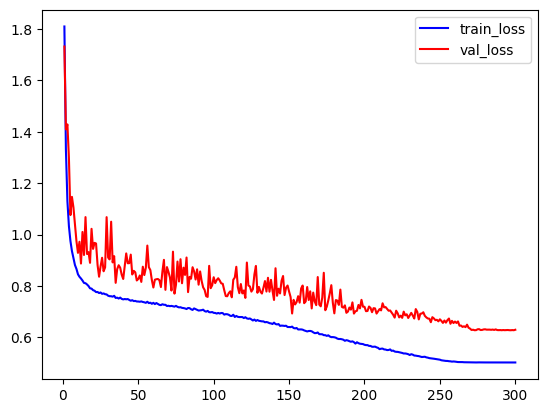

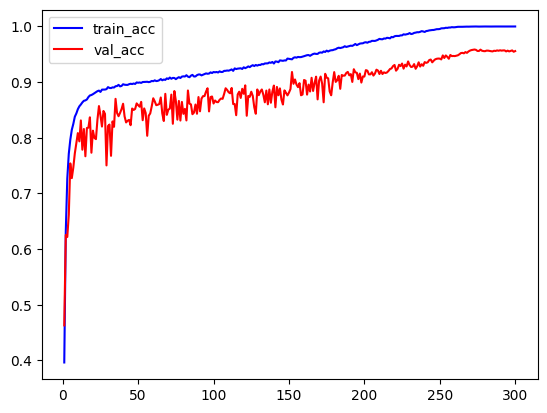

In [13]:
import matplotlib.pyplot as plt, pickle

with open('/kaggle/input/datasets/quphine/model-info-cifar/acc_loss.bin', 'rb') as file:
    loss_dict, acc_dict = pickle.load(file)

plt.figure()
plt.plot([i+1 for i in range(300)], loss_dict['train'], color='b', label='train_loss')
plt.plot([i+1 for i in range(300)], loss_dict['val'], color='r', label='val_loss')
plt.legend()
plt.figure()
plt.plot([i+1 for i in range(300)], acc_dict['train'], color='b', label='train_acc')
plt.plot([i+1 for i in range(300)], acc_dict['val'], color='r', label='val_acc')
plt.legend()

In [13]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


test_dataset   = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = VanillaResNet()
state_dict = torch.load('/kaggle/input/datasets/quphine/model-info-cifar/model_wts.pth')
model.to(device).load_state_dict(state_dict)

model.eval()
y_pred = []
y_label = []
with torch.no_grad():
    for i, (inputs, labels) in enumerate(test_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)
        y_pred.extend(preds.tolist())
        y_label.extend(labels.tolist())

report = classification_report(y_label, y_pred, target_names=classes)
print(report)

matrix = confusion_matrix(y_label, y_pred)
print(matrix)
    
    
    

              precision    recall  f1-score   support

       plane       0.94      0.96      0.95      1000
         car       0.97      0.99      0.98      1000
        bird       0.95      0.92      0.94      1000
         cat       0.89      0.91      0.90      1000
        deer       0.94      0.97      0.95      1000
         dog       0.92      0.91      0.92      1000
        frog       0.96      0.97      0.96      1000
       horse       0.98      0.96      0.97      1000
        ship       0.97      0.96      0.97      1000
       truck       0.98      0.96      0.97      1000

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000

[[956   2  11   4   4   0   3   0  14   6]
 [  1 987   0   0   1   0   0   0   0  11]
 [  7   0 922  15  20  14  13   5   3   1]
 [  7   1   8 910   6  45  15   3   4   1]
 [  4   0   4  11 966   7   5   3   0   0]
 [  2   1   9  56  13 909 